<a href="https://colab.research.google.com/github/patelankit101-max/Agriculture_Crop_Yield_Prediction/blob/main/Agricultural_Crop_Yield_Prediction_Business_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sample Data/crop_production.csv")

print(df.head())
print(df.info())

                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  
3               Banana   176.0       641.0  
4            Cashewnut   720.0       165.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Cr

In [30]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [31]:
df.shape

(246091, 7)

In [8]:
df.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [32]:
df.drop_duplicates(inplace=True)

In [33]:
df = df[df['Area'] > 0]

In [34]:
df['Yield'] = df['Production'] / df['Area']

### Handle Missing Values in Yield
We need to drop rows where `Yield` is NaN, as these cannot be used for training.

In [35]:
print(f"Shape of df before dropping NaNs in Yield: {df.shape}")
df.dropna(subset=['Yield'], inplace=True)
print(f"Shape of df after dropping NaNs in Yield: {df.shape}")

# Verify that there are no more NaNs in Yield
print("Number of NaNs in Yield after dropping:", df['Yield'].isnull().sum())

Shape of df before dropping NaNs in Yield: (246091, 8)
Shape of df after dropping NaNs in Yield: (242361, 8)
Number of NaNs in Yield after dropping: 0


In [36]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


Yield Distribution


In [45]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('all_plots.pdf')

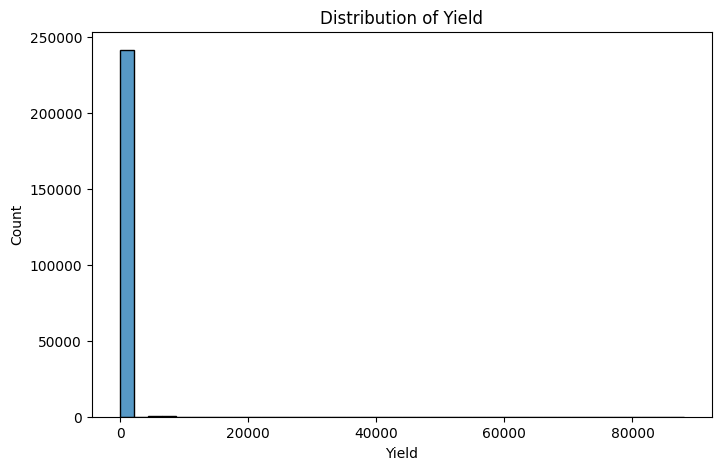

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield'], bins=40)
plt.title('Distribution of Yield')
pdf.savefig(plt.gcf())
plt.show()

Crop-wise Yield


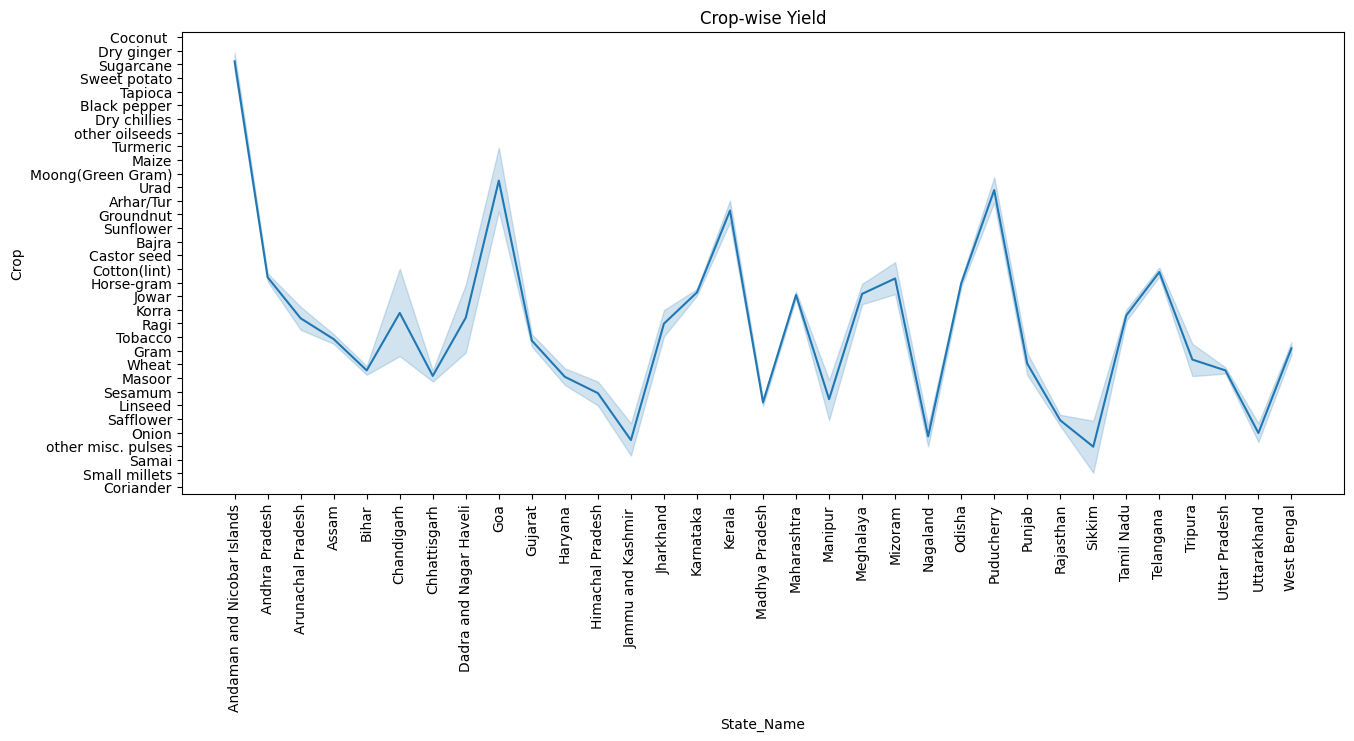

In [39]:
plt.figure(figsize=(15,6))
sns.lineplot(x='State_Name', y='Crop', data=df)
plt.xticks(rotation=90)
plt.title('Crop-wise Yield')
pdf.savefig(plt.gcf())
plt.show()

Season-wise Yield


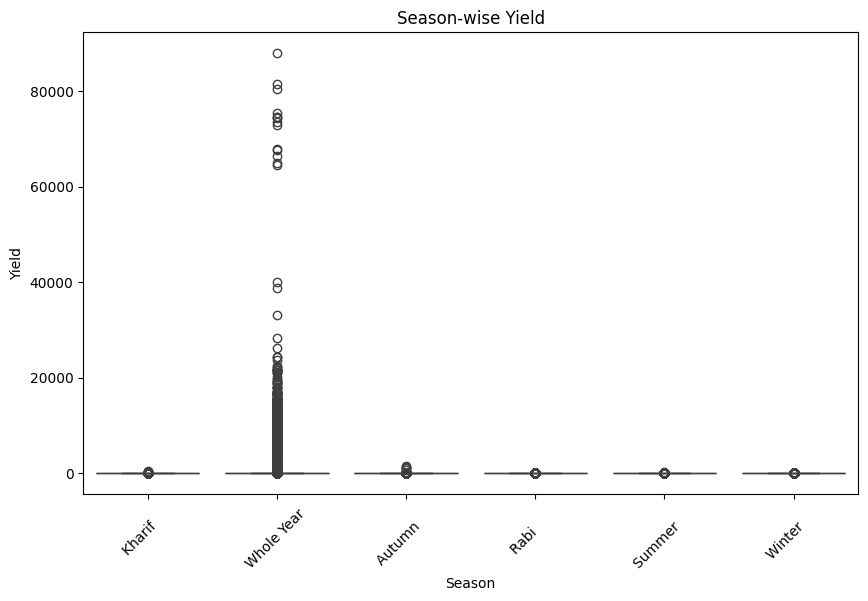

In [41]:
plt.figure(figsize=(10,6)) # Added figure for consistent saving
sns.boxplot(x='Season', y='Yield', data=df)
plt.xticks(rotation=45)
plt.title('Season-wise Yield')
pdf.savefig(plt.gcf())
plt.show()

Year-wise Yield

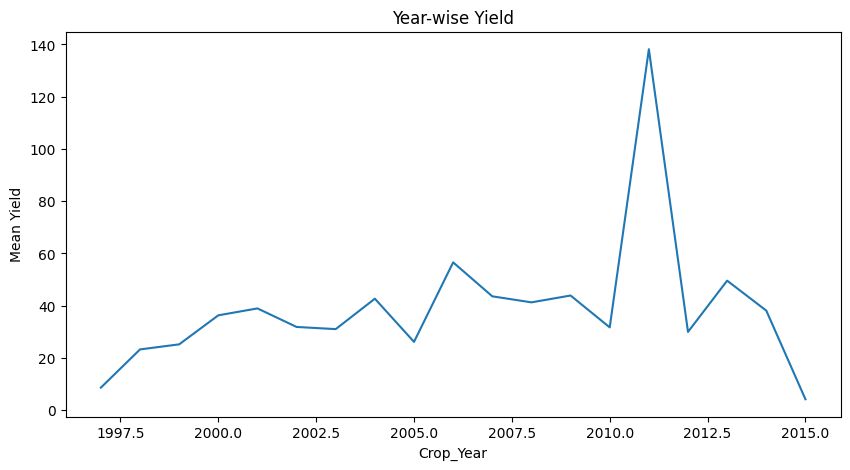

In [47]:
plt.figure(figsize=(10,5)) # Explicitly create a figure
df.groupby('Crop_Year')['Yield'].mean().plot()
plt.title('Year-wise Yield') # Add title for clarity in PDF
plt.xlabel('Crop_Year') # Add xlabel for clarity in PDF
plt.ylabel('Mean Yield') # Add ylabel for clarity in PDF
pdf.savefig(plt.gcf())
plt.show()

Top 10 Crops

In [48]:
df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)

,Yield
Crop,
Coconut,4040.403568
Sugarcane,195.003397
Papaya,28.659374
Banana,27.064755
Grapes,19.229891
Tapioca,18.773412
Pineapple,13.996944
Potato,12.867025
Cabbage,11.920462


Correlation


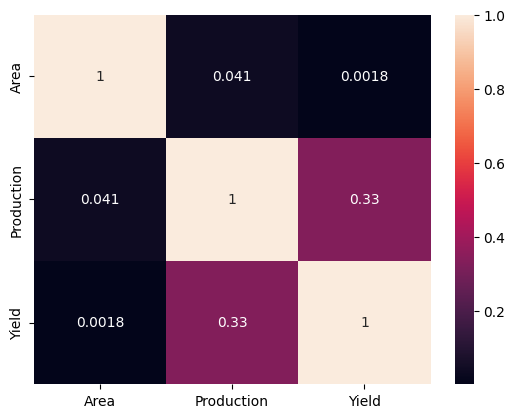

In [49]:
sns.heatmap(df[['Area','Production','Yield']].corr(), annot=True)
pdf.savefig(plt.gcf())
plt.show()

**Feature Engineering**

In [53]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder instances
state_encoder = LabelEncoder()
district_encoder = LabelEncoder()
season_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

# Create encoded columns (original columns remain unchanged)
df['State_Name_Encoded'] = state_encoder.fit_transform(df['State_Name'])
df['District_Name_Encoded'] = district_encoder.fit_transform(df['District_Name'])
df['Season_Encoded'] = season_encoder.fit_transform(df['Season'])
df['Crop_Encoded'] = crop_encoder.fit_transform(df['Crop'])

# Save encoders
joblib.dump(state_encoder, "state_encoder.pkl")
joblib.dump(district_encoder, "district_encoder.pkl")
joblib.dump(season_encoder, "season_encoder.pkl")
joblib.dump(crop_encoder, "crop_encoder.pkl")

# Features for training
X = df[['State_Name_Encoded',
        'District_Name_Encoded',
        'Crop_Year',
        'Season_Encoded',
        'Crop_Encoded',
        'Area']]

# Target variable
y = df['Yield']

# Display original dataframe
print(df.head())

                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    

                  Crop    Area  Production     Yield  State_Name_Encoded  \
0             Arecanut  1254.0      2000.0  1.594896                   0   
1  Other Kharif pulses     2.0         1.0  0.500000                   0   
2                 Rice   102.0       321.0  3.147059                   0   
3               Banana   176.0       641.0  3.642045                   0   
4            Cashewnut   720.0       165.0  0.229167                   0   

   District_Name_Encoded  Season_Encoded  Crop_Encoded  
0                    427               1             

**Train-Test Split**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(193888, 6)
(48473, 6)


**Linear Regression**

In [55]:
import joblib

lr = LinearRegression()
lr.fit(X_train,y_train)

# Save the Linear Regression model
joblib.dump(lr, "linear_regression_model.pkl")

['linear_regression_model.pkl']

**Decision Tree**

In [56]:
import joblib

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

# Save the Decision Tree model
joblib.dump(dt, "decision_tree_model.pkl")

['decision_tree_model.pkl']

**Random Forest**

In [57]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

**Gradient Boosting**

In [59]:
import joblib

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)

# Save the Gradient Boosting model
joblib.dump(gb, "gradient_boosting_model.pkl")

['gradient_boosting_model.pkl']

**Evaluate Models**

In [61]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test,pred)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    r2 = r2_score(y_test,pred)

    results.append([name,mae,rmse,r2])

results = pd.DataFrame(results,
                       columns=["Model","MAE","RMSE","R2"])

results.sort_values("R2",ascending=False)

,Model,MAE,RMSE,R2
2,Random Forest,11.110989,308.123868,0.824502
1,Decision Tree,13.765570,452.211887,0.621988
3,Gradient Boosting,52.909701,536.858875,0.467227
0,Linear Regression,93.610900,732.440999,0.008330


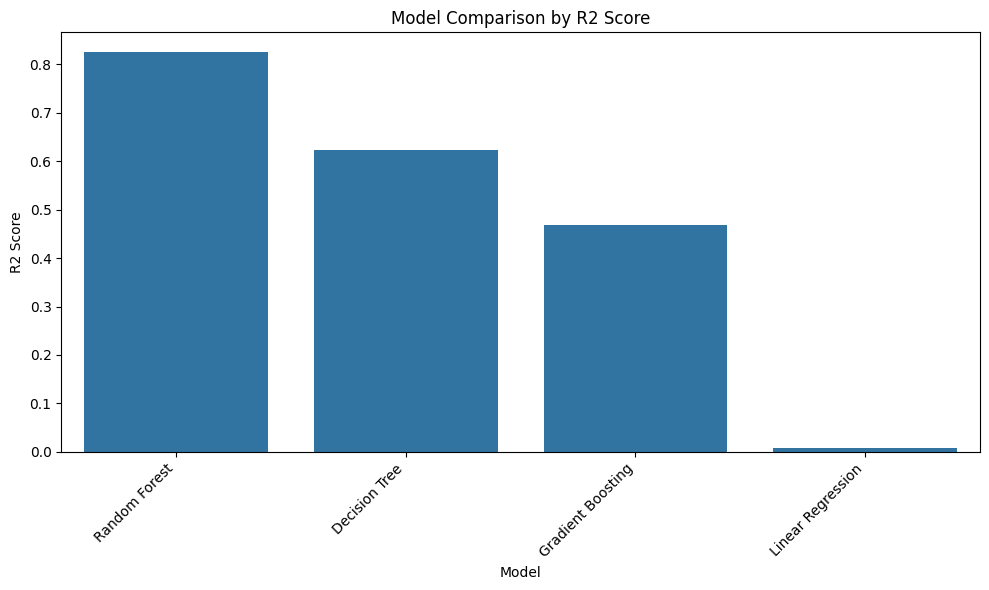

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=results.sort_values(by='R2', ascending=False))
plt.title('Model Comparison by R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
pdf.savefig(plt.gcf())
plt.show()

**Hyperparameter Tuning**

In [63]:
from sklearn.model_selection import GridSearchCV
import joblib

params = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

# Save the best model after tuning
joblib.dump(best_model,"crop_yield_model.pkl")

['crop_yield_model.pkl']

In [64]:
pred_best_model = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, pred_best_model)
rmse_best = np.sqrt(mean_squared_error(y_test, pred_best_model))
r2_best = r2_score(y_test, pred_best_model)

print(f"Best Model (Tuned Random Forest) Metrics:")
print(f"  MAE: {mae_best:.2f}")
print(f"  RMSE: {rmse_best:.2f}")
print(f"  R2: {r2_best:.4f}")

Best Model (Tuned Random Forest) Metrics:
  MAE: 10.99
  RMSE: 307.03
  R2: 0.8257


**Actual vs Predicted**

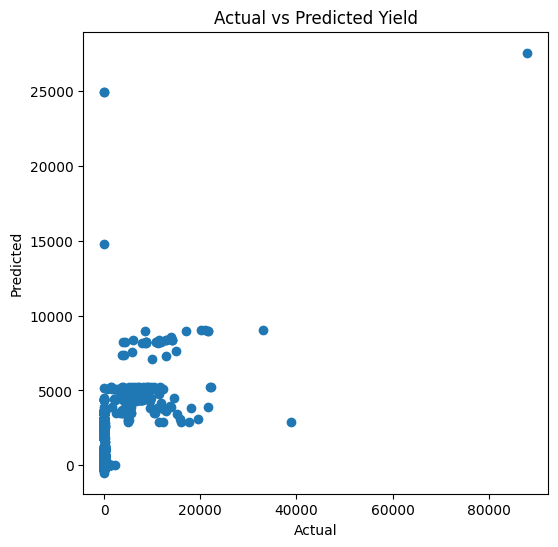

In [65]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Yield")
pdf.savefig(plt.gcf())
plt.show()

**Feature Importance**

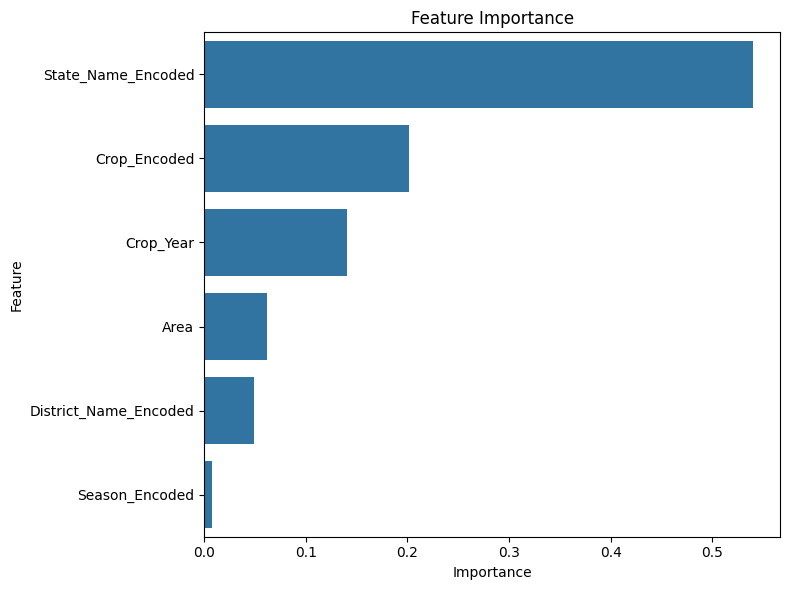

In [66]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values('Importance',ascending=False)

plt.figure(figsize=(8,6)) # Explicitly create a figure and set size
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance') # Add title for clarity in PDF
plt.tight_layout() # Adjust layout
pdf.savefig(plt.gcf())
plt.show()

In [67]:
pdf.close()
print('All plots saved and PDF finalized as all_plots.pdf')

All plots saved and PDF finalized as all_plots.pdf


**High and Low Productivity Districts**

## Dashboard Setup and Execution Guide

To ensure your Streamlit dashboard runs correctly and is accessible via `ngrok`, please follow these steps precisely:

1.  **Set NGROK_AUTH_TOKEN**: Make sure you have set your `NGROK_AUTH_TOKEN` in Colab's 'Secrets' (the 🔑 icon on the left panel). This is crucial for `ngrok` to work.

2.  **Install Dependencies**: Run the cell that installs `streamlit` and `pyngrok` (cells right after this one).

3.  **Create `app.py`**: Run the `%%writefile app.py` cell (`mkUR2IXt1MVW`) to create or update your Streamlit application file.

4.  **Run Streamlit Application**: Execute the cell (`5BRnKn3g1dKt`) that starts the Streamlit application in the background. It will print 'Starting Streamlit app in the background...'. This cell is designed to run non-blockingly, so you can proceed to the next step immediately after starting it.

5.  **Start `ngrok` Tunnel**: Execute the `ngrok` setup cell (`39939b30`). This cell will now wait for the Streamlit app to be ready before establishing the tunnel. Once connected, it will provide you with the public URL.

If you make any changes to `app.py` or encounter issues, **stop both the Streamlit app cell and the ngrok tunnel cell (if running)**, and then repeat steps 3-5.

In [68]:
district = df.groupby('District_Name')['Yield'].mean().reset_index()

top10 = district.sort_values('Yield',ascending=False).head(10)

bottom10 = district.sort_values('Yield').head(10)

print(top10)

print(bottom10)

          District_Name        Yield
189             FAZILKA  2925.533141
451           PATHANKOT  2874.415099
643               YANAM  1520.845456
367                MAHE  1267.923966
501         S.A.S NAGAR   895.493719
290            KARAIKAL   721.161490
187     FATEHGARH SAHIB   684.942192
289          KAPURTHALA   622.846012
424          NAWANSHAHR   550.880984
587  THIRUVANANTHAPURAM   498.287170
    District_Name     Yield
485        RAMBAN  0.649892
397        MUMBAI  0.666667
62         BARMER  0.838955
439       PALGHAR  0.882184
125         CHURU  0.914057
165          DODA  0.956268
478       RAJAURI  1.013577
582         THANE  1.027008
474        RAIGAD  1.086286
318      KISHTWAR  1.111396


**Install Streamlit**

In [69]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 63.7 MB/s eta 0:00:00


**Create app.py**

In [78]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

st.set_page_config(page_title="Crop Yield Prediction", layout="wide")

st.title("🌾 Agricultural Crop Yield Prediction")

st.write("Predict crop yield using Machine Learning")

# ------------------------
# Data Loading and Preprocessing (required for plots)
# ------------------------

@st.cache_data # Cache data loading for performance
def load_and_preprocess_data():
    df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sample Data/crop_production.csv")
    df.drop_duplicates(inplace=True)
    df = df[df['Area'] > 0]
    df['Yield'] = df['Production'] / df['Area']
    df.dropna(subset=['Yield'], inplace=True)
    return df

df = load_and_preprocess_data()

# Load encoders
state_encoder = joblib.load("state_encoder.pkl")
district_encoder = joblib.load("district_encoder.pkl")
season_encoder = joblib.load("season_encoder.pkl")
crop_encoder = joblib.load("crop_encoder.pkl")

# Create encoded columns (original columns remain unchanged)
df['State_Name_Encoded'] = state_encoder.transform(df['State_Name'])
df['District_Name_Encoded'] = district_encoder.transform(df['District_Name'])
df['Season_Encoded'] = season_encoder.transform(df['Season'])
df['Crop_Encoded'] = crop_encoder.transform(df['Crop'])

# Features for training
X = df[['State_Name_Encoded', 'District_Name_Encoded', 'Crop_Year', 'Season_Encoded', 'Crop_Encoded', 'Area']]
y = df['Yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------
# Load Models and Calculate Metrics
# ------------------------

@st.cache_resource # Cache models to avoid reloading on each rerun
def load_models():
    lr_model = joblib.load("linear_regression_model.pkl")
    dt_model = joblib.load("decision_tree_model.pkl")
    rf_model = joblib.load("crop_yield_model.pkl") # Tuned Random Forest (best_model)
    gb_model = joblib.load("gradient_boosting_model.pkl")
    return {
        "Linear Regression": lr_model,
        "Decision Tree": dt_model,
        "Random Forest": rf_model,
        "Gradient Boosting": gb_model
    }

loaded_models = load_models()

# Evaluate all models to get their metrics for the comparison chart and display
results = []
for name, model in loaded_models.items():
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append([name, mae, rmse, r2])

model_performance_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
model_performance_df.set_index("Model", inplace=True)

# Define performance metrics for each model based on current evaluation
model_performance = model_performance_df.to_dict(orient='index')


# ------------------------
# Sidebar
# ------------------------

st.sidebar.header("Enter Crop Details")

# Model Selection Dropdown
selected_model_name = st.sidebar.selectbox(
    "Select Model",
    list(loaded_models.keys())
)

# Set the current model based on selection
model = loaded_models[selected_model_name]

# Using original classes for selectbox to display meaningful names
selected_state = st.sidebar.selectbox(
    "State",
    state_encoder.classes_
)

selected_district = st.sidebar.selectbox(
    "District",
    district_encoder.classes_
)

selected_crop = st.sidebar.selectbox(
    "Crop",
    crop_encoder.classes_
)

slected_season = st.sidebar.selectbox(
    "Season",
    season_encoder.classes_
)

year = st.sidebar.number_input(
    "Crop Year",
    min_value=1997,
    max_value=2035,
    value=2023
)

area = st.sidebar.number_input(
    "Cultivated Area (Hectare)",
    min_value=0.1,
    value=1.0
)

# Encode selected values for model prediction
state_encoded = state_encoder.transform([selected_state])[0]
district_encoded = district_encoder.transform([selected_district])[0]
crop_encoded = crop_encoder.transform([selected_crop])[0]
season_encoded = season_encoder.transform([slected_season])[0]

input_data = pd.DataFrame({
    "State_Name_Encoded":[state_encoded],
    "District_Name_Encoded":[district_encoded],
    "Crop_Year":[year],
    "Season_Encoded":[season_encoded],
    "Crop_Encoded":[crop_encoded],
    "Area":[area]
})

if st.sidebar.button("Predict Yield"): # Changed to sidebar button
    prediction = model.predict(input_data)[0]
    st.success(f"Predicted Crop Yield : {prediction:.2f}")

# ------------------------
# Main Content - Model Performance and Plots
# ------------------------

st.subheader(f"Model Performance ({selected_model_name})")
current_metrics = model_performance[selected_model_name]
st.metric("R² Score", f"{current_metrics['R2']:.2f}")
st.metric("RMSE", f"{current_metrics['RMSE']:.2f}")
st.metric("MAE", f"{current_metrics['MAE']:.2f}")

st.markdown("### Model Comparison")
fig_r2_comparison = plt.figure(figsize=(10, 6))
sns.barplot(x=model_performance_df.index, y='R2', data=model_performance_df.sort_values(by='R2', ascending=False))
plt.title('Model Comparison by R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
st.pyplot(fig_r2_comparison)

st.markdown(f"### Actual vs Predicted Yield ({selected_model_name})")
fig_actual_predicted = plt.figure(figsize=(8, 6))
pred_selected = model.predict(X_test)
plt.scatter(y_test, pred_selected, alpha=0.6)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Actual vs Predicted Yield for {selected_model_name}")
st.pyplot(fig_actual_predicted)

# Feature Importance for tree-based models
if selected_model_name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
    st.markdown(f"### Feature Importance ({selected_model_name})")
    # Re-calculate importance for the selected model if it's tree-based
    # Note: For Linear Regression, feature_importances_ does not exist directly.
    if hasattr(model, 'feature_importances_'):
        importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': model.feature_importances_
        })
        importance = importance.sort_values('Importance', ascending=False)

        fig_feature_importance = plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=importance)
        plt.title(f'Feature Importance for {selected_model_name}')
        plt.tight_layout()
        st.pyplot(fig_feature_importance)
    else:
        st.write("Feature importance is not directly available for this model type.")



Overwriting app.py


**Run the Dashboard**

In [80]:
import subprocess
import time

# Run Streamlit in the background
# It's crucial to run this cell *before* the ngrok tunnel cell (`39939b30`).
# This command will start Streamlit and allow it to run persistently.
print("Starting Streamlit app in the background...")
process = subprocess.Popen(['streamlit', 'run', 'app.py'])

# Give Streamlit a moment to initialize and bind to its port (8501)
time.sleep(5)

# Keep this cell running to keep Streamlit alive
# You can stop this cell when you are done using the Streamlit app.
try:
    while True:
        time.sleep(60) # Sleep for a minute, keeping the process alive
except KeyboardInterrupt:
    print("Stopping Streamlit app.")
    process.terminate()
    process.wait()

Starting Streamlit app in the background...


Stopping Streamlit app.


### Expose Streamlit App with ngrok

To access your Streamlit application from your local browser, we'll use `ngrok` to create a secure tunnel to the port where Streamlit is running (default is `8501`).

First, install `pyngrok`.

In [71]:
pip install pyngrok

Next, you'll need an `ngrok` authentication token. If you don't have one, you can get it from the [ngrok dashboard](https://dashboard.ngrok.com/get-started/your-authtoken) after signing up. Store it securely in Colab's Secrets manager as `NGROK_AUTH_TOKEN` (under the '🔑' icon in the left panel).

In [79]:
from pyngrok import ngrok
from google.colab import userdata

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Authenticate ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Create a public URL for port 8501 (Streamlit's default port)
public_url = ngrok.connect(addr='8501', bind_tls=True)
print(f'Streamlit App URL: {public_url}')

# Keep the cell running to maintain the tunnel. You might need to move the !streamlit run app.py command into a separate cell and run it *after* this cell.

Streamlit App URL: NgrokTunnel: "https://fa3e-34-44-255-165.ngrok-free.app" -> "http://localhost:8501"


Now, open the `Streamlit App URL` printed above in your web browser. If you run into issues, try restarting the `!streamlit run app.py` cell and then the `ngrok` cell.